In [1]:

from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.policies import BasePolicy
from stable_baselines3.common.torch_layers import FlattenExtractor
from stable_baselines3.dqn import DQN
from stable_baselines3.common.callbacks import BaseCallback

import torch as th
import gymnasium as gym
from torchinfo import summary


from game_environment import cache_directory_files, USStockEnv, USStockEnvFragmented, FLOAT_TYPE

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sumTreeBatched import PrioritizedExperienceReplayBuffer  # python buffer
# from per_buffer import PrioritizedExperienceReplayBuffer    # c++ buffer
from pprint import pprint
from typing import Tuple, NamedTuple, List, Callable,Any, Optional,Union


th.set_float32_matmul_precision('high')
# import tf_agents.networks.categorical_q_network

In [2]:
# # Data Collection
tickers = ["AAPL", "TSLA", "MSFT", "META", "GOOG", "AMZN", "NVDA","AVGO","JPM","WMT", "LLY","NFLX","V","ORCL","MA","XOM","JNJ","BAC","PLTR","ABBV"]
check_ticker = "^GSPC"

# from USstockHelper import create_previous_data_file, printStaticGraph
# date_str = "2025-10-03" 
# create_previous_data_file([check_ticker]+tickers, date_str=date_str)
# # printStaticGraph(date_str, check_ticker)
    

In [3]:
# ------------------------------
# Training & Evaluation
# ------------------------------
num_iterations           = 250000           # Total number of training iterations, each call to each env.step is counted as 1 iteration.
log_interval             = 20                # Full Episodes between scalar/log prints
num_eval_episodes        = 4                # Episodes to run per evaluation
eval_interval            = 5000             # Steps between evaluations
stats_window_size        = 10               # Window size for rolling stats, average over these many episodes
verbose                  = 2                # debug mode
seed                     = 0                # set up seed
device                   = "auto"           # device selection (CPU/GPU)
dtype                    =  th.from_numpy(np.array(0,dtype=FLOAT_TYPE)).dtype

# ------------------------------
# Experience Replay
# ------------------------------
replay_buffer_capacity    = 2**17            # Replay buffer size
initial_collect_steps     = int(0.01*replay_buffer_capacity)  # collect of iterations
batch_size                = 32              # Samples drawn per training step
num_prev_file             = 10               # Number of previous steps to include in historical average

# ------------------------------
# Environment & Episode Configuration
# ------------------------------
train_frequency          = int(0.001*replay_buffer_capacity)            # How many experiences to collect per step (learn step)
gradient_steps           = int(0.5*train_frequency)              # How many times to update online model per step (learn step)
N_step                   = 1                # Number of steps used in n-step return
T                        = N_step + 1      # Total frames in each training sequence
L                        = 15               # Total number of observations in each state

# ------------------------------
# Return & Reward Scaling
# ------------------------------
gamma                    = 0.999            # Discount factor for future rewards
reward_scalar            = 1500              # Factor by which raw rewards are scaled in environment

# ------------------------------
# Target Network Updates
# ------------------------------
target_update_tau        = 0.1               # Soft-update interpolation factor
target_update_period     = 250                # Steps between hard-copy target updates

# ------------------------------
# Learning Rate Schedule
# ------------------------------
init_lr                  = FLOAT_TYPE(5e-4 )            # Starting learning rate
final_lr                  = FLOAT_TYPE(1e-6)            # Minimum learning rate for both subnetworks

# ------------------------------
# Exploration (ε-Greedy)
# ------------------------------
epsilon_start             = FLOAT_TYPE(0.8)             # Starting ε (fully random)
epsilon_end               = FLOAT_TYPE(0.01)             # Final ε after decay
exploration_fraction      = 0.85              # Fraction of total training over which ε decays

# ------------------------------
# Regularization & Gradient Control
# ------------------------------
regularization            = 0.0              # L2 regularization strength
max_grad_norm             = 10               # Maximum gradient value


In [4]:
""" Loading Data and Creating Environments """
train_dir = "../US_Market_Data"         # for training
eval_dir = "../US_Market_Data/^GSPC"    # for test data

train_cache = cache_directory_files(directory=train_dir, exclude_sub_dir=eval_dir, num_prev_file=num_prev_file)
test_cache = cache_directory_files(directory=eval_dir, num_prev_file=num_prev_file)


""" Creating the ennvironments """
# training environment, just for training, no evaluations
train_py_env = USStockEnvFragmented( train_cache, reward_scalar, L)
# eval environment, only for evaluations, no training, passed to called. 
eval_py_env = USStockEnvFragmented( train_cache, reward_scalar, L)
# test environments for both literal money and average return 
test_py_env = USStockEnvFragmented(test_cache, reward_scalar, L)


print(f"observation_space:{train_py_env.observation_space}")
print(f"action_space:{train_py_env.action_space}")

print("train env check:")
check_env(train_py_env)
print("test env check:")
check_env(test_py_env)

print(f"{len(train_cache)} training files, {len(test_cache)} test files")

observation_space:Dict('compound': Box(-inf, inf, (6,), float32), 'dependent': Box(-inf, inf, (15, 4), float32), 'independent': Box(-inf, inf, (15, 6), float32))
action_space:Int16Discrete(9)
train env check:
test env check:
1149 training files, 110 test files


/home/yansh/Documents/RLFinance/.venv/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:272: UserWarning: Your observation dependent has an unconventional shape (neither an image, nor a 1D vector). We recommend you to flatten the observation to have only a 1D vector or use a custom policy to properly process the data.
  warnings.warn(
/home/yansh/Documents/RLFinance/.venv/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:272: UserWarning: Your observation independent has an unconventional shape (neither an image, nor a 1D vector). We recommend you to flatten the observation to have only a 1D vector or use a custom policy to properly process the data.
  warnings.warn(


In [5]:
class CustomNetwork(BasePolicy):
    """
    PyTorch implementation of the Keras CustomNetwork, as a subclass of the SB3 QNetwork.
    Expects `obs` to be a dict-like with keys: 'independent', 'dependent', 'compound'.
    All computations done in `dtype`
    """

    class InnerNetwork(th.nn.Module):
        """Handles everything after LSTM outputs: MLPs, residuals, and categorical heads."""
        def __init__(self, main_mlp, value_head, advantage_head, supports, actions, atoms):
            super().__init__()
            self.main_mlp = main_mlp
            self.value_head = value_head
            self.advantage_head = advantage_head
            self.supports = supports
            self.num_actions = actions
            self.num_atoms = atoms

        def forward(self, ind_out, dep_out, compound_out):
            # concat LSTM embeddings + compound
            x = th.cat([ind_out, dep_out, compound_out], dim=-1)

            # residual main MLP
            for block in self.main_mlp:
                x = th.nn.functional.gelu(block(x) + x)

            # categorical heads
            value_logits = self.value_head(x).view(-1, 1, self.num_atoms)
            advantage_logits = self.advantage_head(x).view(-1, self.num_actions, self.num_atoms)
            logits = value_logits + advantage_logits - advantage_logits.mean(dim=1, keepdim=True)
            probs = th.softmax(logits, dim=-1)
            q_values = th.sum(probs * self.supports, dim=-1)
            return q_values
        
    def __init__(self, observation_space, action_space, dtype=dtype, name="CustomNetwork"):
            super().__init__(observation_space, action_space)
            self._name = name
            self.dtype = dtype
            self.num_actions = int(action_space.n)

            # --- categorical net params ---
            self.num_atoms = 51
            self.min_q_val = -10
            self.max_q_val = 10
            self.supports = th.linspace(
                self.min_q_val,
                self.max_q_val,
                self.num_atoms,
                dtype=self.dtype,
                device="cuda"
                ).view(1, 1, -1)
            
            # --- sizes and layers ---
            ind_input_size = observation_space.spaces["independent"].shape[-1]
            dep_input_size = observation_space.spaces["dependent"].shape[-1]
            comp_input_size = observation_space.spaces["compound"].shape[-1]

            main_mlp_size = 512
            lstm_size = int(main_mlp_size/3)
            comp_mlp_size = main_mlp_size - 2*lstm_size

            main_mlp_layers = 12
            compound_mlp_layers = 3
            lstm_mlp_layers = 3

            # --- LSTMs (leave uncompiled) ---
            self.ind_lstm = th.nn.LSTM(ind_input_size, lstm_size, batch_first=True, dtype=dtype)
            self.dep_lstm = th.nn.LSTM(dep_input_size, lstm_size, batch_first=True, dtype=dtype)

            # --- MLP for LSTM Outputs and compound mlp ---
            layers = []
            for i in range(lstm_mlp_layers):
                layers += [
                    th.nn.Linear(lstm_size , lstm_size, dtype=dtype),
                    th.nn.LayerNorm(lstm_size, dtype=dtype),
                    th.nn.SiLU(),
                ]
            self.ind_mlp = th.nn.Sequential(*layers)

            layers = []
            for i in range(lstm_mlp_layers):
                layers += [
                    th.nn.Linear(lstm_size , lstm_size, dtype=dtype),
                    th.nn.LayerNorm(lstm_size, dtype=dtype),
                    th.nn.SiLU(),
                ]
            self.dep_mlp = th.nn.Sequential(*layers)


            layers = []
            for i in range(compound_mlp_layers):
                layers += [
                    th.nn.Linear(comp_input_size if i == 0 else comp_mlp_size, comp_mlp_size, dtype=dtype),
                    th.nn.LayerNorm(comp_mlp_size, dtype=dtype),
                    th.nn.SiLU(),
                ]
            self.compound_mlp = th.nn.Sequential(*layers)


            # main MLP
            self.main_mlp = th.nn.ModuleList()
            for _ in range(main_mlp_layers):
                block = th.nn.Sequential(
                    th.nn.Linear(main_mlp_size, main_mlp_size, dtype=dtype),
                    th.nn.LayerNorm(main_mlp_size, dtype=dtype),
                    th.nn.LeakyReLU(),
                    th.nn.Linear(main_mlp_size, main_mlp_size, dtype=dtype),
                    th.nn.LayerNorm(main_mlp_size, dtype=dtype)
                )
                self.main_mlp.append(block)

            # Normal versions of heads
            # self.value_head = (th.nn.Linear(main_mlp_size, 1, dtype=dtype))
            # self.advantage_head = th.nn.Linear(main_mlp_size, self._num_actions, dtype=dtype)
            
            # Categorical versions
            self.value_head = (th.nn.Linear(main_mlp_size, 1*self.num_atoms, dtype=dtype))
            self.advantage_head = th.nn.Linear(main_mlp_size, self.num_actions*self.num_atoms, dtype=dtype)

            self.inner_network = th.compile( self.InnerNetwork(
                self.main_mlp,
                self.value_head,
                self.advantage_head,
                self.supports,
                self.num_actions,
                self.num_atoms)
                ,mode="reduce-overhead"
            )

    def forward(self, obs: dict, deterministic: bool = True) -> th.Tensor:
        # LSTM outputs
        ind_out, _ = self.ind_lstm(obs["independent"])
        ind_out = self.ind_mlp(ind_out[:, -1, :])
        if th.isnan(ind_out).any() or th.isinf(ind_out).any():
            print("NaN/Inf detected in ind_out")

        dep_out, _ = self.dep_lstm(obs["dependent"])
        dep_out = self.dep_mlp(dep_out[:, -1, :])
        if th.isnan(dep_out).any() or th.isinf(dep_out).any():
            print("NaN/Inf detected in dep_out")

        compound_out = self.compound_mlp(obs["compound"])
        if th.isnan(compound_out).any() or th.isinf(compound_out).any():
            print("NaN/Inf detected in compound_out")

        q_values = self.inner_network(ind_out, dep_out, compound_out)
        if th.isnan(q_values).any() or th.isinf(q_values).any():
            print("NaN/Inf detected in q_values")
            raise ValueError()

        return q_values


    def _get_constructor_parameters(self) -> dict[str, Any]:
        data = super()._get_constructor_parameters()
        data.update(self._constructor_parameters)
        return data
    
    def _predict(self, observation:dict, deterministic = False): NotImplementedError()

class DDQNPolicy(BasePolicy):
    """
    Double DQN Policy with separate Q-network and target Q-network.

    Similar interface to DQNPolicy for SB3 compatibility, but implements DDQN.
    """

    q_net: th.nn.Module
    q_net_target: th.nn.Module

    def __init__(
        self,
        observation_space: gym.spaces.Space,
        action_space: gym.spaces.Discrete,
        lr_schedule: Callable[[float], float],
        optimizer_class: type[th.optim.Optimizer] = th.optim.Adam,
        optimizer_kwargs: Optional[dict[str, Any]] = None,
    ):
        super().__init__(
            observation_space,
            action_space,
            features_extractor_class = FlattenExtractor,
            features_extractor_kwargs = None,
            optimizer_class=optimizer_class,
            optimizer_kwargs=optimizer_kwargs,
            normalize_images=False,  # placeholder, not used
        )
        self.lr_schedule = lr_schedule
        self._build(lr_schedule)

    def _build(self, lr_schedule: Callable[[float], float]) -> None:
        """Create Q-networks and optimizer, and set target net to eval mode."""
        self.q_net = self.make_q_net()
        self.q_net_target = self.make_q_net()
        self.q_net_target.load_state_dict(self.q_net.state_dict())
        self.q_net_target.eval() # target net never trained
        # self.q_net = th.compile(self.q_net, mode="reduce-overhead", fullgraph=True)
        # self.q_net_target = th.compile(self.q_net_target, mode="reduce-overhead", fullgraph=True)


        self.optimizer = self.optimizer_class(
            self.q_net.parameters(),
            lr=lr_schedule(1),
            **self.optimizer_kwargs,
        )

    def make_q_net(self) -> th.nn.Module:
        # For DDQN, just make a copy of the network (features extractor ignored)
        return CustomNetwork(self.observation_space, self.action_space).to(self.device)

    def forward(self, obs: dict, deterministic: bool = True) -> th.Tensor:
        """
        Forward pass returns q-values from the main network.
        """
        # Expect dict obs: {"independent":..., "dependent":..., "compound":...}
        return self.q_net(obs, deterministic)
    
    def _predict(self, obs:dict, deterministic = False):
        return th.argmax(self.forward(obs, deterministic=deterministic), dim =-1)

    def set_training_mode(self, mode: bool) -> None:
        self.q_net.train(mode)
        self.training = mode

    def _get_constructor_parameters(self) -> dict[str, Any]:
        data = super()._get_constructor_parameters()
        data.update(
            dict(
                lr_schedule=lambda x: 1e-3,  # dummy schedule for saving/loading
                optimizer_class=self.optimizer_class,
                optimizer_kwargs=self.optimizer_kwargs,
                features_extractor_class=self.features_extractor_class,
                features_extractor_kwargs=self.features_extractor_kwargs,
            )
        )
        return data

class DDQN(DQN):
    def train(self, gradient_steps: int, batch_size: int) -> None:
        # Switch to train mode (this affects batch norm / dropout)
        self.policy.set_training_mode(True)
        # Update learning rate according to schedule
        self._update_learning_rate(self.policy.optimizer)

        losses = []
        for _ in range(gradient_steps):
            # Sample replay buffer
            replay_data = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)  # type: ignore[union-attr]
            # For n-step replay, discount factor is gamma**n_steps (when no early termination)
            discounts = replay_data.discounts if replay_data.discounts is not None else self.gamma
            
            with th.no_grad():
                next_q_values = self.q_net(replay_data.next_observations)        # [B,A] Q(s',a) from main net
                best_actions = th.argmax(next_q_values, dim=-1)                  # [B] argmax_a Q(s',a)
                target_q_values = self.q_net_target(replay_data.next_observations)  # [B,A] Q(s',a) from target net
                target_q_values = th.gather(target_q_values, dim=-1, index=best_actions.unsqueeze(-1))  # [B,1] select best actions
                target_q_values = replay_data.rewards + (1 - replay_data.dones) * discounts * target_q_values  # [B,1] TD target


            # Get current Q-values estimates
            current_q_values = self.q_net(replay_data.observations)

            # Retrieve the q-values for the actions from the replay buffer
            current_q_values = th.gather(current_q_values, dim=1, index=replay_data.actions.long())

            # Compute Huber loss (less sensitive to outliers)
            loss = th.nn.functional.smooth_l1_loss(current_q_values, target_q_values)
            losses.append(loss.item())

            # Optimize the policy
            self.policy.optimizer.zero_grad()
            loss.backward()
            # Clip gradient norm
            th.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
            self.policy.optimizer.step()

        # Increase update counter
        self._n_updates += gradient_steps

        self.logger.record("train/n_updates", self._n_updates, exclude="tensorboard")
        self.logger.record("train/loss", np.mean(losses))

class GeometricSchedule:
    def __init__(self, init_lr: float, final_lr: float):
        self.init_lr = init_lr
        self.final_lr = final_lr
        self.lr = None

    def __call__(self, progress_remaining: float) -> float:
        self.lr = self.final_lr * (self.init_lr / self.final_lr) ** progress_remaining
        return self.lr

    def __repr__(self) -> str:
        return f"GeometricSchedule(init_lr={self.init_lr}, final_lr={self.final_lr})"

class TradingMetricsCallback(BaseCallback):
    def __init__(self, eval_interval, train_env, test_env, num_eval_episodes=10, verbose=0):
        super(TradingMetricsCallback, self).__init__(verbose)
        self.eval_interval = eval_interval
        self.train_env = train_env
        self.test_env = test_env
        self.num_eval_episodes = num_eval_episodes

        # Storage for metrics
        self.training_loss = []
        self.training_q_values = []
        self.train_return = []
        self.train_money = []
        self.train_count = []
        self.test_return = []
        self.test_money = []
        self.test_count = []
        
    def _on_step(self) -> bool:
        # Only evaluate at specified frequency
        if not self.n_calls % self.eval_interval == 0: # dont do anything in case n_calls is not a multiple of eval interval
            return True 

        step = self.n_calls
        
        """ Train Metrics """
        avg_return, avg_money_pct, avg_count = self.evaluate_episode_metrics(self.train_env)
        
        self.train_return.append(avg_return)
        self.train_money.append(avg_money_pct)
        self.train_count.append(avg_count)
        
        print(f"step = {step}: Train: Count = {avg_count:.5f}, Money = {avg_money_pct:.5f}, Reward = {avg_return:.5f}")
        
        """ Test Metrics """
        avg_return, avg_money_pct, avg_count = self.evaluate_episode_metrics(self.test_env)
        
        self.test_return.append(avg_return)
        self.test_money.append(avg_money_pct)
        self.test_count.append(avg_count)
        
        print(f"step = {step}: Test: Count = {avg_count:.5f}, Money = {avg_money_pct:.5f}, Reward = {avg_return:.5f}")
        
        """ Training Metrics """
        #Loss
        loss_value = self.model.logger.name_to_value.get("train/loss", np.nan)
        self.training_loss.append(loss_value)
        
        #QValues
        batch_size = min(32, self.model.replay_buffer.buffer_size)
        replay_data = self.model.replay_buffer.sample(batch_size)
        
        # Get Q-values for sampled states
        self.model.q_net.eval()
        with th.no_grad():
            q_values = self.model.q_net(replay_data.observations)
            avg_q_values = q_values.mean(dim=0).cpu().numpy()  # Average over batch
            self.training_q_values.append(avg_q_values)
        self.model.q_net.train()        # set backk to training mode

        """ Printing LR Test stuff """
        # print(f"step = {step}: Loss = {loss_value}, LR = {self.model.learning_rate.lr}, Progress = {self.model._current_progress_remaining}")
        return True
    
    def evaluate_episode_metrics(self, env):
        """
        Evaluate the policy and return average return, money percentage, and trade count
        """
        all_returns = []
        all_moneys = []
        all_counts = []
        
        for _ in range(self.num_eval_episodes):
            obs, _ = env.reset() # reset returns obs, eval_reward_dict
            done = False
            episode_return = 0
            episode_trade = 0
            episode_money = 0
            
            while not done:
                action, _states = self.model.predict(obs, deterministic=True) # model = algorithm, so this is dqn.predict
                obs, reward, done, _,  info = env.step(action)

                episode_return += reward
                episode_money += info['eval_reward']
                episode_trade += 1 if info['eval_reward'] != 0.0 else 0 
            
            all_returns.append(episode_return)
            all_moneys.append(episode_money)
            all_counts.append(episode_trade // 2)   # a buy and a sell counts as 1 trade
        
        avg_return = np.mean(all_returns)
        avg_money_pct = np.mean(all_moneys) * 100  # Convert to percentage
        avg_count = np.mean(all_counts)
        
        return avg_return, avg_money_pct, avg_count
    
    def _on_training_end(self):
        # Optional: Do something when training ends
        print("Training completed!")
        
    def get_metrics(self):
        """Return all collected metrics for plotting"""
        return {
            'training_loss': self.training_loss,
            'training_q_values': self.training_q_values,
            'train_return': self.train_return,
            'train_money': self.train_money,
            'train_count': self.train_count,
            'test_return': self.test_return,
            'test_money': self.test_money,
            'test_count': self.test_count
        }
    


In [6]:
# lr_test_lr_schedule = GeometricSchedule(init_lr= 1e-8, final_lr=1.0)

lr_schedule = GeometricSchedule(init_lr,final_lr)
algorithm = DDQN(
    DDQNPolicy,
    train_py_env,
    learning_rate=lr_schedule,
    buffer_size=replay_buffer_capacity,
    learning_starts=initial_collect_steps,     # start when replay buffer is collected
    batch_size=batch_size,
    tau=target_update_tau,
    gamma=gamma,
    train_freq=train_frequency,
    gradient_steps=gradient_steps,
    replay_buffer_class = None,                 # selects DictReplayBuffer
    replay_buffer_kwargs = None,                # selects DictReplayBuffer
    optimize_memory_usage=False,                # Not supported by DictReplayBuffer
    n_steps=N_step,                             # can onl be 1 for DictReplayBuffer
    target_update_interval=target_update_period,
    exploration_fraction = exploration_fraction,
    exploration_initial_eps = epsilon_start,
    exploration_final_eps = epsilon_end,
    max_grad_norm = max_grad_norm,
    stats_window_size = stats_window_size,
    tensorboard_log = None,                     # No tenorboard logging
    policy_kwargs = None,                       # No additional params for policy creation
    verbose = verbose,
    seed = seed,
    device = device,
    _init_setup_model = True                    # Always set up policy and optimizer etc.
)


print("LR schedule: ", algorithm.policy.lr_schedule)
print("Environment: ", algorithm.env)
print("Number of Environment: ", algorithm.env.num_envs)

obs, _ = train_py_env.reset()   # np.ndarray
obs = th.utils._pytree.tree_map(
    lambda x: th.from_numpy(np.expand_dims(x, axis=0).repeat(batch_size, axis=0)).to(device="cuda", dtype=dtype), 
    obs
)
print(summary(algorithm.policy.q_net, input_data=(obs,)))


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
LR schedule:  FloatSchedule(GeometricSchedule(init_lr=0.0005000000237487257, final_lr=9.999999974752427e-07))
Environment:  <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x7c73bd8266f0>
Number of Environment:  1


W1013 15:17:25.393000 125047 torch/_dynamo/convert_frame.py:1016] [5/8] torch._dynamo hit config.recompile_limit (8)
W1013 15:17:25.393000 125047 torch/_dynamo/convert_frame.py:1016] [5/8]    function: 'hook' (/home/yansh/Documents/RLFinance/.venv/lib/python3.12/site-packages/torchinfo/torchinfo.py:592)
W1013 15:17:25.393000 125047 torch/_dynamo/convert_frame.py:1016] [5/8]    last reason: 5/7: global_layer_info[136836538471856].macs == 0           
W1013 15:17:25.393000 125047 torch/_dynamo/convert_frame.py:1016] [5/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1013 15:17:25.393000 125047 torch/_dynamo/convert_frame.py:1016] [5/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


Layer (type:depth-idx)                        Output Shape              Param #
CustomNetwork                                 [32, 9]                   --
├─LSTM: 1-1                                   [32, 15, 170]             121,040
├─Sequential: 1-2                             [32, 170]                 --
│    └─Linear: 2-1                            [32, 170]                 29,070
│    └─LayerNorm: 2-2                         [32, 170]                 340
│    └─SiLU: 2-3                              [32, 170]                 --
│    └─Linear: 2-4                            [32, 170]                 29,070
│    └─LayerNorm: 2-5                         [32, 170]                 340
│    └─SiLU: 2-6                              [32, 170]                 --
│    └─Linear: 2-7                            [32, 170]                 29,070
│    └─LayerNorm: 2-8                         [32, 170]                 340
│    └─SiLU: 2-9                              [32, 170]                 --


In [7]:
eval_callback = TradingMetricsCallback(
    eval_interval=eval_interval, 
    train_env=eval_py_env,
    test_env= test_py_env,
    num_eval_episodes=num_eval_episodes,
    verbose=verbose)

algorithm.learn(
    total_timesteps=num_iterations,
    log_interval=log_interval,
    callback=eval_callback)


step = 5000: Train: Count = 1.00000, Money = 0.11622, Reward = 5.74138
step = 5000: Test: Count = 1.00000, Money = 0.37908, Reward = 6.22800
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 375       |
|    ep_rew_mean      | -142      |
|    exploration_rate | 0.7721177 |
| time/               |           |
|    episodes         | 20        |
|    fps              | 47        |
|    time_elapsed     | 159       |
|    total_timesteps  | 7500      |
| train/              |           |
|    learning_rate    | 0.000415  |
|    loss             | 0.297     |
|    n_updates        | 3055      |
-----------------------------------
step = 10000: Train: Count = 1.00000, Money = 0.00603, Reward = 4.39560
step = 10000: Test: Count = 1.00000, Money = 0.34049, Reward = 4.25335
step = 15000: Train: Count = 1.00000, Money = 0.28106, Reward = 6.22505
step = 15000: Test: Count = 1.00000, Money = 0.11800, Reward = 0.88273
---------------------------------

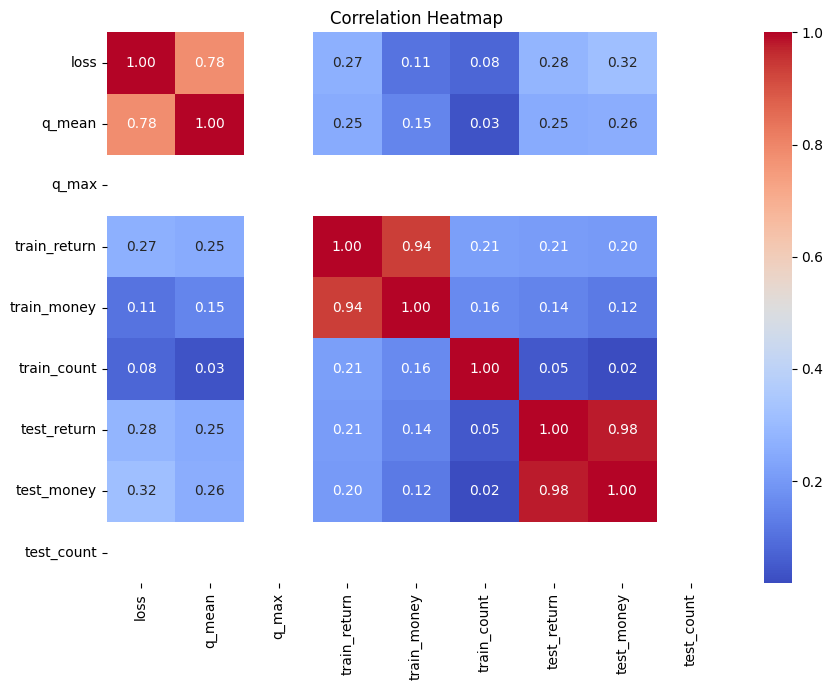

In [8]:
metrics = eval_callback.get_metrics()

training_loss = np.array(metrics["training_loss"])
training_q_values = np.array(metrics["training_q_values"])
train_return = np.array(metrics["train_return"])
train_money =np.array( metrics["train_money"])
train_count =np.array( metrics["train_count"])
test_return = np.array(metrics["test_return"])
test_money =np.array( metrics["test_money"])
test_count = np.array(metrics["test_count"])

# assemble arrays
q_vals = np.array(training_q_values)
q_mean = np.mean(q_vals, axis=1)
q_max  = np.max(q_vals, axis=1)

data = {
    'loss': np.array(training_loss),
    'q_mean': q_mean,
    'q_max': q_max,
    'train_return': np.array(train_return),
    'train_money': np.array(train_money),
    'train_count': np.array(train_count),
    'test_return': np.array(test_return),
    'test_money': np.array(test_money),
    'test_count': np.array(test_count),
}

df = pd.DataFrame(data)
df = pd.DataFrame(data).fillna(0)
# df = pd.read_csv("../temp.csv", index_col=False, header=0)
# Pearson correlation
corr = df.corr(method='pearson').abs()

# # Heatmap
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


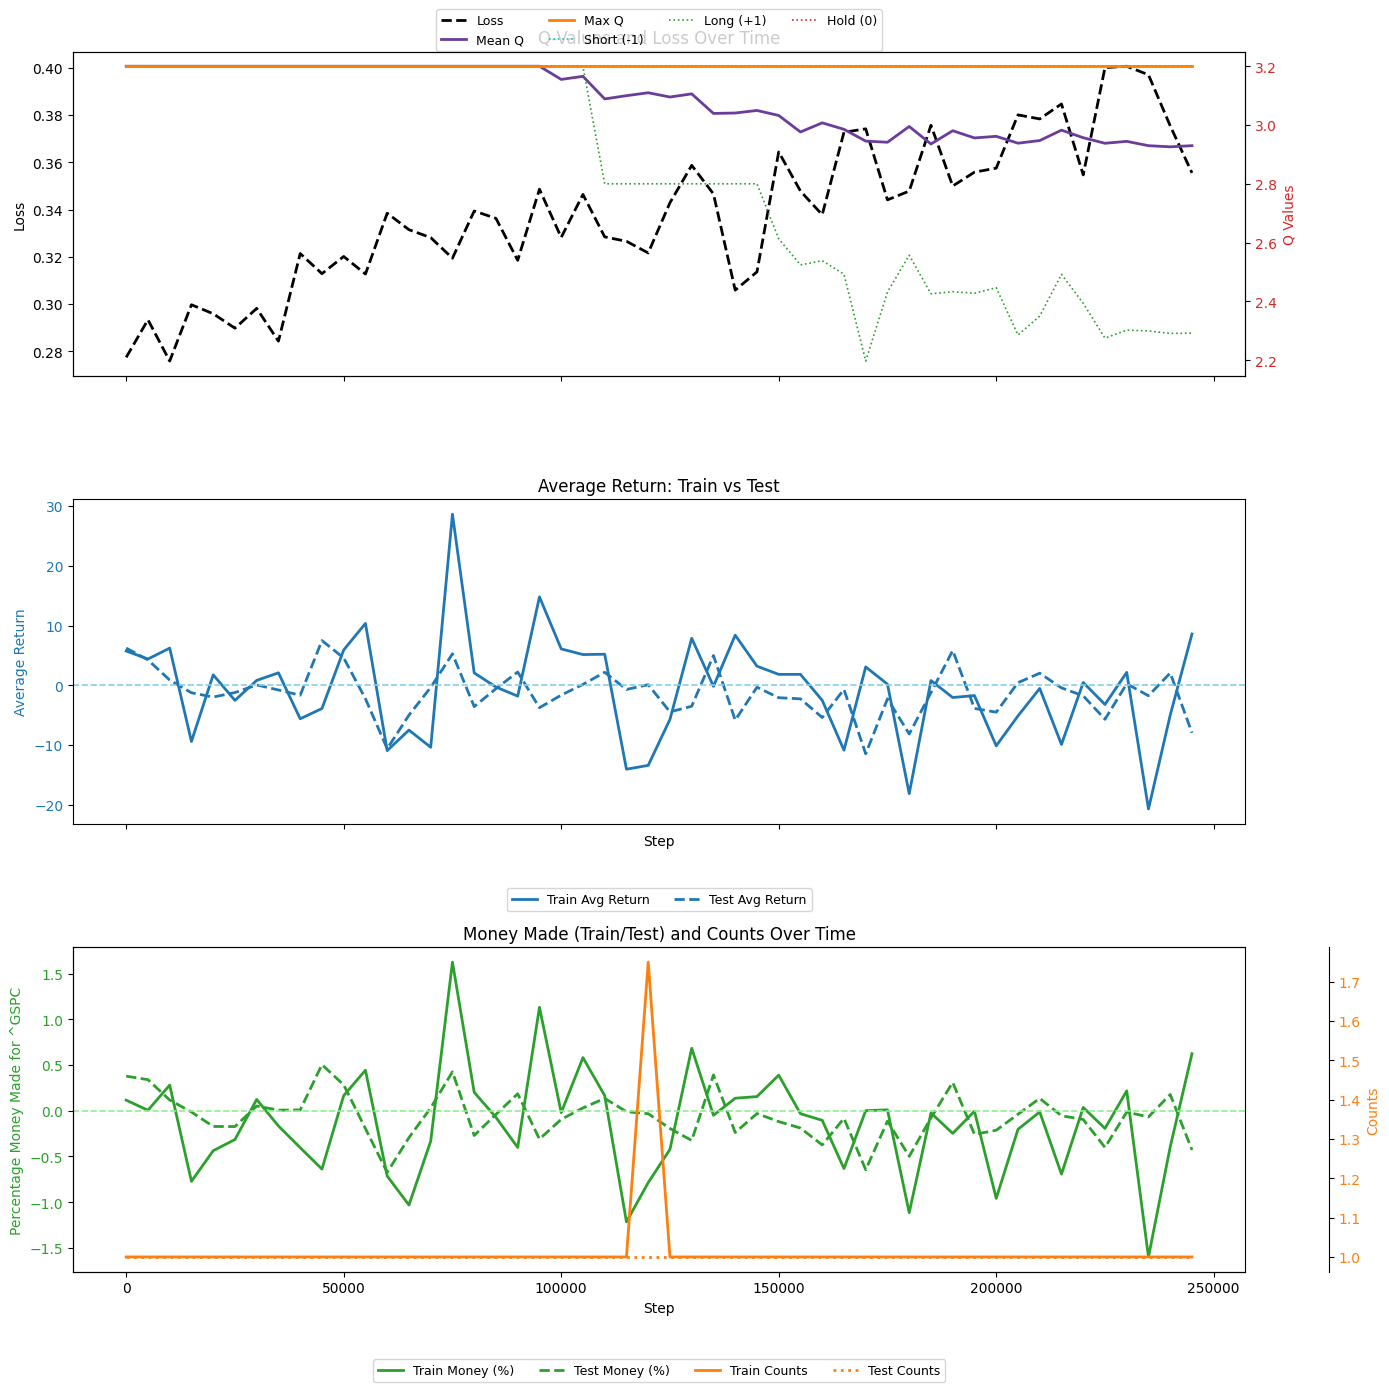

In [9]:
# --- plotting (reorganized middle & bottom plots) ---
# prepare arrays (unchanged)
q_values_array = np.array(training_q_values)            # [num_eval_points, num_actions]
train_return_arr   = np.array(train_return)
train_money_arr    = np.array(train_money)
train_count_arr    = np.array(train_count)

test_return_arr  = np.array(test_return)
test_money_arr   = np.array(test_money)
test_count_arr   = np.array(test_count)

steps = list(range(0, num_iterations, eval_interval))
# Compute mean and max Q over actions
q_mean = np.mean(q_values_array, axis=1)
q_max  = np.max(q_values_array, axis=1)

# Create figure with three subplots stacked vertically
fig, (ax_top, ax_mid, ax_bottom) = plt.subplots(nrows=3, figsize=(14, 14), sharex=True)

# --- Top Plot: Q-values and Loss (unchanged) ---
ax_top.set_ylabel('Loss', color='black')
line_loss = ax_top.plot(steps, training_loss, label='Loss', color='black', linewidth=2, linestyle='dashed')[0]
ax_top.tick_params(axis='y', labelcolor='black')

ax2_top = ax_top.twinx()
ax2_top.set_ylabel('Q Values', color='tab:red')


# Representative Q-values for -1, 0, +1 actions
short_idx = 0                   # first action = full short
hold_idx  = train_py_env._Aq                   # middle action = hold
long_idx  = 2*train_py_env._Aq                 # last action = full long

q_line_short = ax2_top.plot(steps, q_values_array[:, short_idx], 
                            color='tab:cyan', linestyle='dotted', linewidth=1.2, label='Short (-1)')[0]
q_line_no_trade  = ax2_top.plot(steps, q_values_array[:, hold_idx], 
                            color='tab:red', linestyle='dotted', linewidth=1.2, label='Hold (0)')[0]
q_line_long  = ax2_top.plot(steps, q_values_array[:, long_idx], 
                            color='tab:green', linestyle='dotted', linewidth=1.2, label='Long (+1)')[0]

q_line_mean = ax2_top.plot(steps, q_mean, label='Mean Q', color='#6a3d9a', linewidth=2)[0]
q_line_max  = ax2_top.plot(steps, q_max,  label='Max Q',  color='#ff7f00', linewidth=2)[0]

ax2_top.tick_params(axis='y', labelcolor='tab:red')

handles_top = [line_loss, q_line_mean, q_line_max, q_line_short, q_line_long, q_line_no_trade]
labels_top = [h.get_label() for h in handles_top]
ax_top.legend(handles_top, labels_top, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=9)
ax_top.set_title('Q-Values and Loss Over Time')

# --- Middle Plot: Average Return (Train + Test) ---
ax_mid.set_xlabel('Step')
ax_mid.set_ylabel('Average Return', color='tab:blue')
# Both lines blue but different structured lines
train_line_ret = ax_mid.plot(steps, train_return_arr, label='Train Avg Return', color='tab:blue', linewidth=2, linestyle='solid')[0]
test_line_ret = ax_mid.plot(steps, test_return_arr, label='Test Avg Return', color='tab:blue', linewidth=2, linestyle='dashed')[0]
ax_mid.tick_params(axis='y', labelcolor='tab:blue')
ax_mid.axhline(0, color='skyblue', linestyle='dashed', linewidth=1.2, label='Return=0')

handles_mid = [train_line_ret, test_line_ret]
labels_mid = [h.get_label() for h in handles_mid]
ax_mid.legend(handles_mid, labels_mid, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)
ax_mid.set_title('Average Return: Train vs Test')

# --- Bottom Plot: Money Made (as percentage label) and Counts (Both Train + Test) ---
ax_bottom.set_xlabel('Step')
ax_bottom.set_ylabel(f'Percentage Money Made for {check_ticker}', color='tab:green')
# Money lines share the same money axis (green) — legend labels mention Train/Test only
train_line_money = ax_bottom.plot(steps, train_money_arr, label='Train Money (%)', color='tab:green', linewidth=2, linestyle='solid')[0]
test_line_money = ax_bottom.plot(steps, test_money_arr, label='Test Money (%)', color='tab:green', linewidth=2, linestyle='dashed')[0]
ax_bottom.tick_params(axis='y', labelcolor='tab:green')
ax_bottom.axhline(0, color='lightgreen', linestyle='dashed', linewidth=1.2, label='Money=0')

# Counts on a separate right axis
ax2_bottom = ax_bottom.twinx()
ax2_bottom.spines['right'].set_position(('outward', 60))
ax2_bottom.set_ylabel('Counts', color='tab:orange')
train_line_counts = ax2_bottom.plot(steps, train_count_arr, label='Train Counts', color='tab:orange', linewidth=2, linestyle='solid')[0]
test_line_counts = ax2_bottom.plot(steps, test_count_arr, label='Test Counts', color='tab:orange', linewidth=2, linestyle='dotted')[0]
ax2_bottom.tick_params(axis='y', labelcolor='tab:orange')

# Combined legend (money & counts). Money legend entries do not include $check_ticker text.
handles_bottom = [train_line_money, test_line_money, train_line_counts, test_line_counts]
labels_bottom = [h.get_label() for h in handles_bottom]
ax_bottom.legend(handles_bottom, labels_bottom, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=4, fontsize=9)
ax_bottom.set_title('Money Made (Train/Test) and Counts Over Time')

plt.tight_layout()
plt.show()


In [10]:
# save and load the network params, save network and hyperparams manually
path = Path("Network/network_params.pth")
path.parent.mkdir(parents=True, exist_ok=True)

#Saving
th.save(algorithm.policy.q_net.state_dict(), path)

#Loading
# algorithm.policy.q_net.load_state_dict(th.load(path))


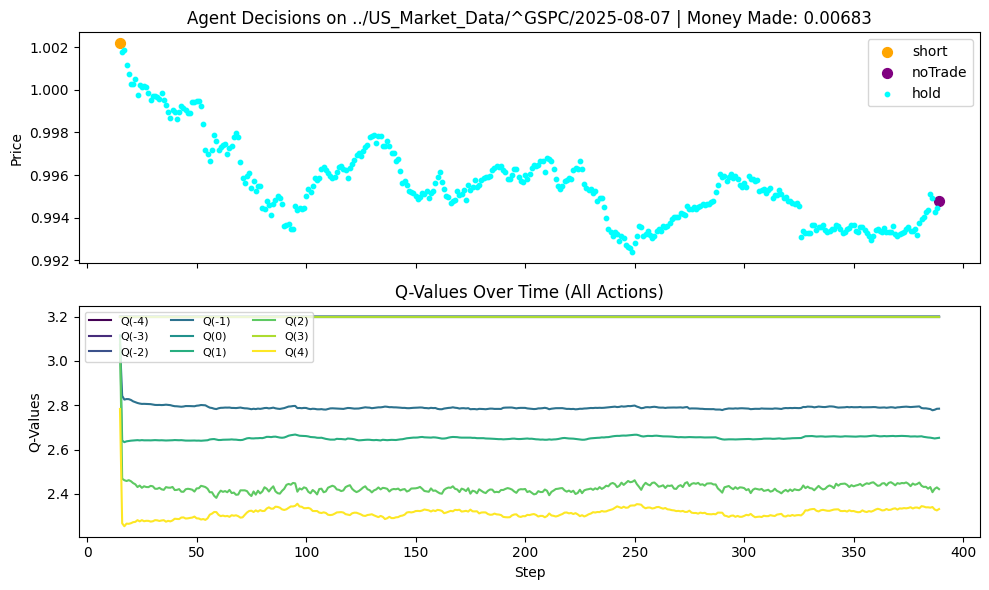

In [17]:
""" Run the algorithm for one test episode: """
step = test_py_env._L - 1
test_py_env.logger = []               # attach logger list (env will append dicts to this)
test_py_env.logging_step = step       # env uses this value for the 'step' field each append
q_values_over_time = []
file_name = test_py_env._FILE_NAME    

# Reset environment (obs, info)
obs, _ = test_py_env.reset()
done = False
# Run exactly one full episode (env will fill test_py_env.logger automatically)
while not done:
    # increment logger step BEFORE env appends next entry (env reads logging_step)
    test_py_env.logging_step += 1

    obs_tnsr = th.utils._pytree.tree_map(
        lambda x: th.from_numpy(np.expand_dims(x, axis=0).repeat(1, axis=0)).to(device="cuda", dtype=dtype), 
        obs
    )

    algorithm.q_net.eval()
    with th.no_grad():
        q_t = algorithm.q_net(obs_tnsr)
    algorithm.q_net.train()

    # q_t shape: [1, n_actions] -> convert to 1D numpy
    q_np = q_t.cpu().numpy().squeeze()
    q_values_over_time.append(q_np)

    # 2) get action from SB3 model (uses same raw obs format as env.reset/step)
    action, _ = algorithm.predict(obs, deterministic=True)

    # 3) step environment: (obs, train_reward, termination, truncation, info)
    obs, _, done, _, _ = test_py_env.step(action)

# --- After episode finished, build DataFrame from env logger (env already wrote entries) ---
df = pd.DataFrame.from_records(test_py_env.logger, index="step")

# Prepopulate with holds and mark changed actions (same logic as TF)
df["plot_category"] = "hold"
change_mask = df["action"] != df["prev_action"]
df.loc[change_mask, "plot_category"] = df.loc[change_mask, "action"]


plot_styles = {
    "short": {"color": "orange", "size": 50, "zorder":1},
    "noTrade": {"color": "purple", "size": 50 ,"zorder":1},
    "long": {"color": "green", "size": 50, "zorder":1},
    "hold": {"color": "cyan", "size": 10, "zorder":2},
}

total_reward = df["eval_reward"].sum()
q_values_array = np.array(q_values_over_time)  # shape [T, n_actions]
steps = df.index.to_numpy()

steps = df.index.to_numpy()
n_actions = q_values_array.shape[1]

# Sanity check: ensure n_actions matches 2*Aq + 1
Aq = train_py_env._Aq
assert n_actions == 2*Aq + 1, f"Expected {2*Aq+1} actions, got {n_actions}"


fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 6), sharex=True)

# Price plot with markers
for cat, style in plot_styles.items():
    mask = df["plot_category"] == cat
    if mask.any():
        ax1.scatter(df.index[mask], df["data"][mask], color=style["color"], s=style["size"], label=cat)

ax1.set_ylabel("Price")
ax1.set_title(f"Agent Decisions on {file_name} | Money Made: {total_reward:.5f}")
ax1.legend()

# Q-values plot
if q_values_array.ndim == 1:
    q_values_array = q_values_array[:, None]  # make (T, 1) for consistency
cmap = plt.get_cmap("viridis", n_actions)

for i in range(n_actions):
    ax2.plot(steps, q_values_array[:, i], label=f"Q({i-Aq})", color=cmap(i))

ax2.set_ylabel("Q-Values")
ax2.set_xlabel("Step")
ax2.set_title("Q-Values Over Time (All Actions)")
ax2.legend(loc="upper left", ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# import itertools
# from collections import Counter

# # params
# K = 3
# S = 1
# dilations = (1,2,2,3)

# # build the flat list of dilations, two layers per dilation per stack
# layers = []
# for _ in range(S):
#     for d in dilations:
#         layers.append(d)   # first conv in residual block
#         layers.append(d)   # second conv in residual block

# # for each layer, the kernel can “pick” any of the K positions {0, 1, …, K-1},
# # which corresponds to an offset of (position * dilation)
# offsets_per_layer = [
#     [pos * d for pos in range(K)]
#     for d in layers
# ]

# # compute all path‐delays (sum of one offset per layer)
# all_delays = (
#     sum(path)
#     for path in itertools.product(*offsets_per_layer)
# )

# # tally them up
# hist = Counter(all_delays)

# # convert Counter to a plain dict
# delay_to_paths = dict(hist)

# pprint(delay_to_paths)

# total_count = 0
# max_path_len = max(list(delay_to_paths.keys()))
# heuristic = int(0.8*max_path_len)
# heuristic_count = 0


# for p_len, count in delay_to_paths.items():
#     total_count += count
#     if p_len < heuristic:
#         heuristic_count += count
    
# print(f"Total count: {total_count}")
# print(f"Heuristic count: {heuristic_count}")
# print(f"Percent of all paths close by heuristic look back period of {heuristic}:  {heuristic_count/total_count*100}")
# print(f"Max Path length {max_path_len}")
# print(f"K:{K}, nb_stacks:{S}, dilations:{dilations}")


In [13]:
# import tensorflow as tf
# import numpy as np
# from tensorflow.keras.optimizers.legacy import Adam
# from tensorflow.keras.optimizers.schedules import PolynomialDecay
# from tf_agents.networks.network import Network
# # Assume CustomNetwork is already defined/imported in your environment

# # --- 1. Generate fake data ---
# # State dimension: Look-back L = 28, feature dim F = 8
# # Action dimension A = 4
# X = np.random.randn(1000, 22, 8).astype(np.float32)
# y = np.random.randn(1000, 4).astype(np.float32)

# # --- 2. Build the network ---
# # Example hyperparameters
# fc_units = [256, 128]       # will be ignored since we freeze heads only
# regularization = 1e-4

# network = CustomNetwork(
#     observation_spec= train_py_env.observation_spec(),  # Replace with your actual spec if needed
#     action_spec=train_py_env.action_spec(),       # Replace with your actual spec if needed
#     fc_layer_params=fc_units,
#     regularization=regularization
# )

# # Unfreeze all layers so gradients flow through both TCN and heads
# for layer in network.layers:
#     layer.trainable = True
#     if layer.name in {"Value_Head", "Advantage_Head"}: layer.trainable =False

# # --- 3. Prepare dataset ---
# dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(32)

# # --- 4. Optimizer and loss ---
# # Learning rate schedule (example)
# init_lr = 1e-4
# num_decay_steps = 1000
# final_lr = 1e-5
# lr_schedule = PolynomialDecay(init_lr, num_decay_steps, final_lr, power=1, cycle=False)
# optimizer = Adam(learning_rate=lr_schedule)
# mse = tf.keras.losses.MeanSquaredError()

# # --- 5. Training step function ---
# @tf.function
# def train_step(x_batch, y_batch):
#     with tf.GradientTape() as tape:
#         q_pred, _ = network(x_batch, training=True)  # [B, A]
#         loss = mse(y_batch, q_pred)
#     grads = tape.gradient(loss, network.trainable_variables)
#     optimizer.apply_gradients(zip(grads, network.trainable_variables))
#     return loss

# # --- 6. Training loop ---
# for epoch in range(100):
#     epoch_loss = 0.0
#     for xb, yb in dataset:
#         batch_loss = train_step(xb, yb)
#         epoch_loss += batch_loss
#     print(f"Epoch {epoch+1}, Loss: {epoch_loss.numpy()/len(dataset):.4f}")
